In [2]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Load CSV
df = pd.read_csv("embedded_systems_education_dataset.csv")
df.dropna(inplace=True)  # Drop missing rows if any

# Create weighted final score
df["final_score"] = (
    df["Assignments Score (%)"] * 0.3 +
    df["Lab Completion (%)"] * 0.2 +
    df["Project-Based Learning Score (%)"] * 0.3 +
    df["Innovation Index (0-100)"] * 0.1 +
    df["Entrepreneurship Engagement (0-100)"] * 0.1
)

# Select features (X) and label (y)
features = [
    "Assignments Score (%)",
    "Lab Completion (%)",
    "Project-Based Learning Score (%)",
    "Innovation Index (0-100)",
    "Entrepreneurship Engagement (0-100)"
]
X = df[features]
y = df["final_score"]


In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the XGBoost regressor
model = xgb.XGBRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [6]:
# Predict on test set
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("R² Score:", round(r2, 2))


Mean Absolute Error (MAE): 1.82
Mean Squared Error (MSE): 5.1
R² Score: 0.92


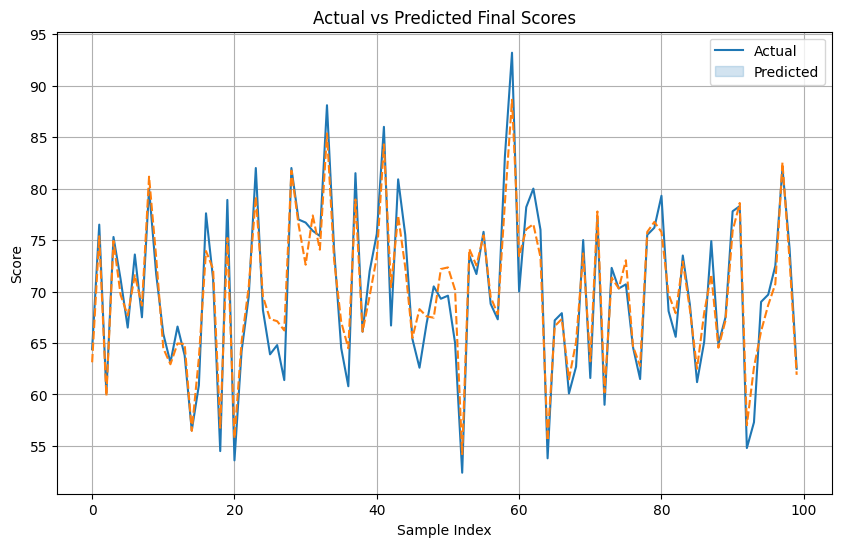

In [7]:
# Compare actual vs predicted
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
}).reset_index(drop=True)

plt.figure(figsize=(10,6))
sns.lineplot(data=comparison_df, palette="tab10")
plt.title("Actual vs Predicted Final Scores")
plt.xlabel("Sample Index")
plt.ylabel("Score")
plt.legend(["Actual", "Predicted"])
plt.grid(True)
plt.show()


In [8]:
import joblib
joblib.dump(model, "final_score_model_xgboost.pkl")


['final_score_model_xgboost.pkl']

In [9]:
# Example input: 1 student's data
new_student = pd.DataFrame([{
    "Assignments Score (%)": 78,
    "Lab Completion (%)": 84,
    "Project-Based Learning Score (%)": 80,
    "Innovation Index (0-100)": 60,
    "Entrepreneurship Engagement (0-100)": 70
}])


In [10]:
predicted_score = model.predict(new_student)
print(f"Predicted Final Score: {predicted_score[0]:.2f}")


Predicted Final Score: 76.75


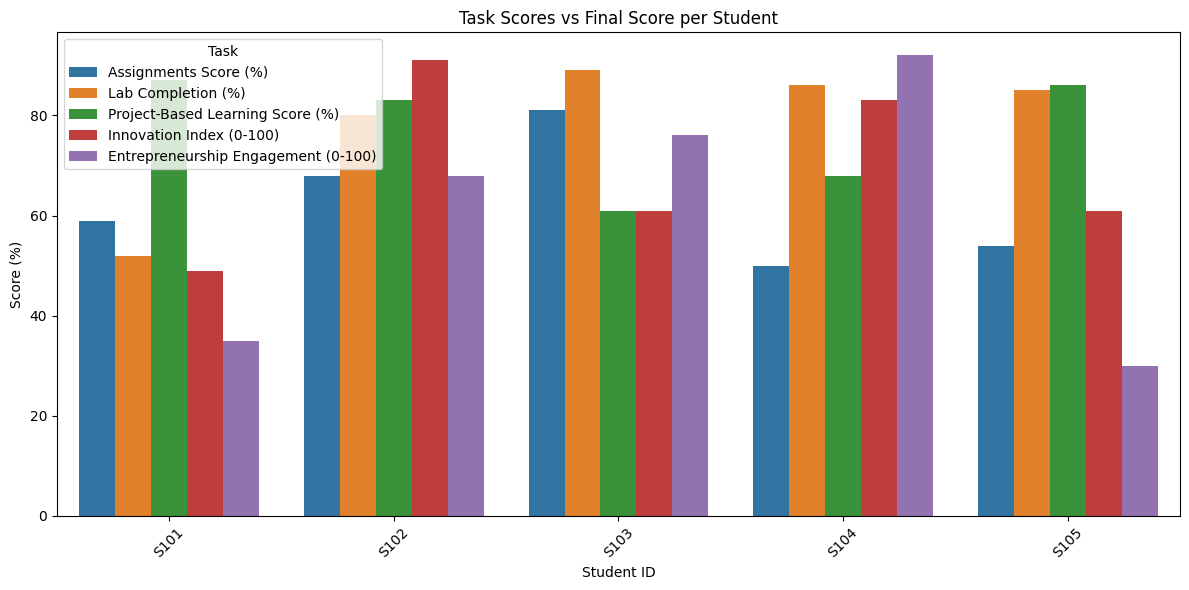

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("embedded_systems_education_dataset.csv")
df.dropna(inplace=True)

# Calculate final_score
df["final_score"] = (
    df["Assignments Score (%)"] * 0.3 +
    df["Lab Completion (%)"] * 0.2 +
    df["Project-Based Learning Score (%)"] * 0.3 +
    df["Innovation Index (0-100)"] * 0.1 +
    df["Entrepreneurship Engagement (0-100)"] * 0.1
)

# Take only first 5 students to avoid overload
sample_df = df.head(5)

# Melt for seaborn
melted = sample_df[[
    "Student ID",
    "Assignments Score (%)",
    "Lab Completion (%)",
    "Project-Based Learning Score (%)",
    "Innovation Index (0-100)",
    "Entrepreneurship Engagement (0-100)",
    "final_score"
]].melt(id_vars=["Student ID", "final_score"], var_name="Task", value_name="Score")

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=melted, x="Student ID", y="Score", hue="Task")
plt.title("Task Scores vs Final Score per Student")
plt.ylabel("Score (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\Shahizmeer\AppData\Local\Temp\ipykernel_16780\522156928.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=student_scores, x="Category", y="Score (%)", palette="viridis")


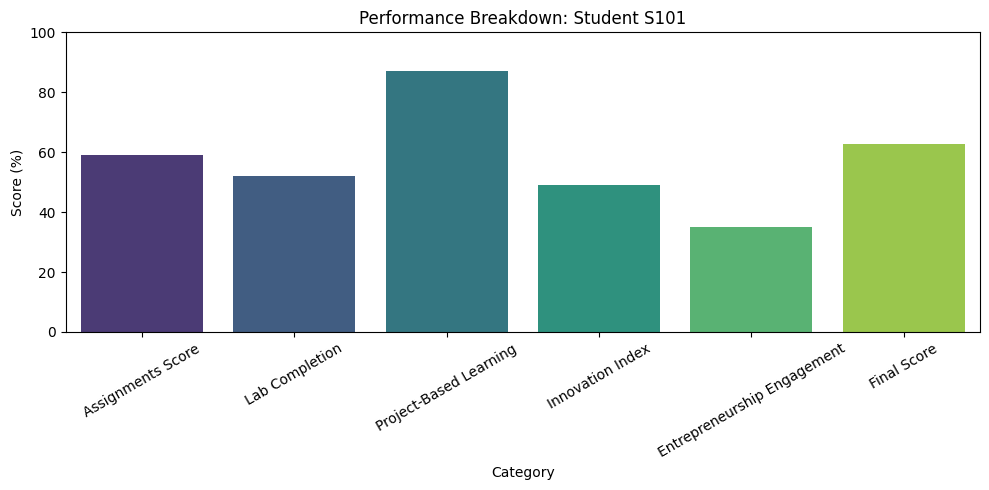

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and prepare data
df = pd.read_csv("embedded_systems_education_dataset.csv")
df.dropna(inplace=True)

# Calculate final score
df["final_score"] = (
    df["Assignments Score (%)"] * 0.3 +
    df["Lab Completion (%)"] * 0.2 +
    df["Project-Based Learning Score (%)"] * 0.3 +
    df["Innovation Index (0-100)"] * 0.1 +
    df["Entrepreneurship Engagement (0-100)"] * 0.1
)

# Pick a student by row index (e.g., student 0)
student = df.iloc[0]  # change index if needed

# Prepare data for plotting
student_scores = pd.DataFrame({
    "Category": [
        "Assignments Score",
        "Lab Completion",
        "Project-Based Learning",
        "Innovation Index",
        "Entrepreneurship Engagement",
        "Final Score"
    ],
    "Score (%)": [
        student["Assignments Score (%)"],
        student["Lab Completion (%)"],
        student["Project-Based Learning Score (%)"],
        student["Innovation Index (0-100)"],
        student["Entrepreneurship Engagement (0-100)"],
        student["final_score"]
    ]
})

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=student_scores, x="Category", y="Score (%)", palette="viridis")
plt.title(f"Performance Breakdown: Student {student['Student ID']}")
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()
